In [1]:
from pathlib import Path
import numpy as np
import xesmf as xe
import xarray as xr
import xcdat as xc
import scipy.sparse as sp

In [2]:
rootdir = Path("/glade/campaign/collections/rda/data/d651010/global/CESM2.1_GOGA_ERSSTv5/atm/proc/tseries/month_1/TREFHT")
ds_1deg = xc.open_dataset(rootdir / "f.e21.FHIST_BGC.f09_f09.historical.ersstv5.goga.ens01.cam.h0.TREFHT.188001-201412.nc")
# ds_1deg = ds_1deg.rename_vars(lat_bnds="lat_b", lon_bnds="lon_b")

rootdir = Path("/glade/campaign/univ/uwas0155/ppe/historical/coupled_simulations/f.e21.FHIST_BGC.f19_f19_mg17.historical.coupPPE.000/atm/proc/tseries/month_1")
ds_2deg = xc.open_dataset(rootdir / "f.e21.FHIST_BGC.f19_f19_mg17.historical.coupPPE.000.cam.h0.TREFHT.195001-201412.nc")
# ds_2deg = ds_2deg.rename_vars(lat_bnds="lat_b", lon_bnds="lon_b")

src_lat = ds_1deg["lat"]
src_lon = ds_1deg["lon"]

tgt_lat = ds_2deg["lat"]
tgt_lon = ds_2deg["lon"] 

source_grid_shape = (ds_1deg.sizes["lat"], ds_1deg.sizes["lon"])
target_grid_shape = (ds_2deg.sizes["lat"], ds_2deg.sizes["lon"])

n_src = ds_1deg.sizes["lat"] * ds_1deg.sizes["lon"]
n_tgt = ds_2deg.sizes["lat"] * ds_2deg.sizes["lon"]

print(f"source: n = {n_src}, shape = {source_grid_shape}, lat = [{src_lat.min().data}, {src_lat.max().data}], lon = [{src_lon.min().data}, {src_lon.max().data}]")
print(f"target: n = {n_tgt}, shape = {target_grid_shape}, lat = [{tgt_lat.min().data}, {tgt_lat.max().data}], lon = [{tgt_lon.min().data}, {tgt_lon.max().data}]")

source: n = 55296, shape = (192, 288), lat = [-90.0, 90.0], lon = [0.0, 358.75]
target: n = 13824, shape = (96, 144), lat = [-90.0, 90.0], lon = [0.0, 357.5]


In [3]:
# def fv_lat_bounds(lat_centers):
#     """FV grid latitude bounds: half-width polar cells bounded by ±90."""
#     bounds = np.zeros(len(lat_centers) + 1)
#     bounds[1:-1] = (lat_centers[:-1] + lat_centers[1:]) / 2
#     bounds[0]  = -90.0
#     bounds[-1] =  90.0
#     return bounds

# def lon_bounds(lon_centers, spacing):
#     """Standard uniform-spacing longitude bounds, periodic."""
#     return np.concatenate([lon_centers - spacing / 2, [lon_centers[-1] + spacing / 2]])

# # --- source grid (1 deg, 192 x 288) ---
# lat_1d_src = ds_1deg.lat.values          # shape (192,)
# lon_1d_src = ds_1deg.lon.values          # shape (288,)
# lat_b_src  = fv_lat_bounds(lat_1d_src)              # shape (193,)
# lon_b_src  = lon_bounds(lon_1d_src, spacing=1.25)   # shape (289,)

# ds_src_grid = xr.Dataset(
#     coords=dict(
#         lat=("lat", lat_1d_src),
#         lon=("lon", lon_1d_src),
#         lat_b=("lat_b", lat_b_src),
#         lon_b=("lon_b", lon_b_src),
#     )
# )

# # --- target grid (2 deg, 96 x 144) ---
# lat_1d_dst = ds_2deg.lat.values          # shape (96,)
# lon_1d_dst = ds_2deg.lon.values          # shape (144,)
# lat_b_dst  = fv_lat_bounds(lat_1d_dst)              # shape (97,)
# lon_b_dst  = lon_bounds(lon_1d_dst, spacing=2.5)    # shape (145,)

# ds_dst_grid = xr.Dataset(
#     coords=dict(
#         lat=("lat", lat_1d_dst),
#         lon=("lon", lon_1d_dst),
#         lat_b=("lat_b", lat_b_dst),
#         lon_b=("lon_b", lon_b_dst),
#     )
# )

# regridder = xe.Regridder(
#     ds_src_grid, ds_dst_grid,
#     method="conservative",
#     periodic=True,             # required for global lon wraparound with conservative method
#     filename="weights_1deg_to_2deg_conservative_fixed.nc",
#     reuse_weights=False,
# )

In [4]:
regridder = xe.Regridder(
    ds_1deg, ds_2deg,
    method="conservative",
    periodic=True,             # required for global lon wraparound with conservative method
    filename="weights_1deg_to_2deg_conservative.nc",
    reuse_weights=False,
)

In [10]:
w = xr.open_dataset("weights_1deg_to_2deg_conservative.nc")
# w = xr.open_dataset("weights_1deg_to_2deg_conservative_fixed.nc")
row = w["row"].values - 1   # xESMF/ESMF weight files are typically 1-indexed
col = w["col"].values - 1
S   = w["S"].values

print(row.max(), col.max())

13823 55295


In [11]:
# sanity check against index maxima
assert row.max() < n_tgt, f"row.max()={row.max()} exceeds n_tgt={n_tgt} — grid mismatch"
assert col.max() < n_src, f"col.max()={col.max()} exceeds n_src={n_src} — grid mismatch"

In [12]:
# W[j, i] = weight a_i of source cell i contributing to target cell j
W = sp.csr_matrix((S, (row, col)), shape=(n_tgt, n_src))

In [13]:
row_sums = np.asarray(W.sum(axis=1)).ravel()
row_sums_2d = row_sums.reshape((96, 144))
print("South pole row sum stats:", row_sums_2d[0, :].min(), row_sums_2d[0, :].max())
print("North pole row sum stats:", row_sums_2d[-1, :].min(), row_sums_2d[-1, :].max())
print("n affected at lat row 0:", np.isclose(row_sums_2d[0, :], row_sums_2d[0, :].min(), atol=1e-4).sum())
print("n affected at lat row -1:", np.isclose(row_sums_2d[-1, :], row_sums_2d[-1, :].min(), atol=1e-4).sum())

South pole row sum stats: 0.9999999999999868 1.000000000000017
North pole row sum stats: 0.9999999999999868 1.0000000000000102
n affected at lat row 0: 144
n affected at lat row -1: 144


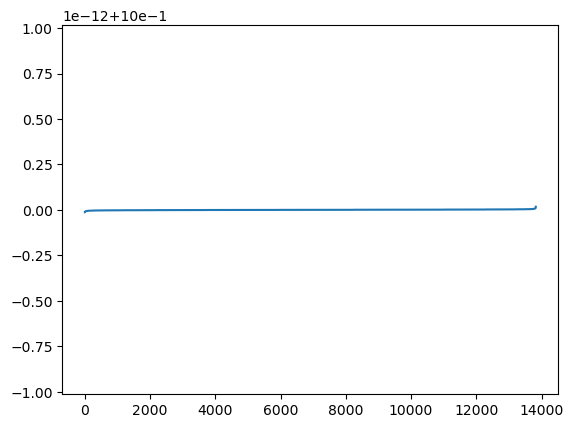

In [14]:
import matplotlib.pyplot as plt

plt.plot(np.arange(len(row_sums)), np.sort(row_sums))

In [16]:
rootdir = Path("/glade/work/bbuchovecky/fhist_ppe_analysis/proc/dist/TREFHT_pool_90d_window")
stats_1deg = xr.open_dataset(rootdir / "GOGA2_TREFHT_pool_90d_window_19850101-20141231_anom_stats.nc")
stats_2deg = xr.open_dataset(rootdir / "GOGA2_2DEG_TREFHT_pool_90d_window_19850101-20141231_anom_stats.nc")

In [24]:
qdelta_1deg = stats_1deg.quantiles.isel(member=1) - stats_1deg.quantiles.isel(member=0)
qdelta_left_shift_1deg = qdelta_1deg.sel(quantile=0.50) - qdelta_1deg.sel(quantile=0.05)
qdelta_right_shift_1deg = qdelta_1deg.sel(quantile=0.95) - qdelta_1deg.sel(quantile=0.50)

qdelta_2deg = stats_2deg.quantiles.isel(member=1) - stats_2deg.quantiles.isel(member=0)
qdelta_left_shift_2deg = qdelta_2deg.sel(quantile=0.50) - qdelta_2deg.sel(quantile=0.05)
qdelta_right_shift_2deg = qdelta_2deg.sel(quantile=0.95) - qdelta_2deg.sel(quantile=0.50)

In [31]:
qdelta_right_shift_1deg_flat = qdelta_right_shift_1deg.values.flatten()
qdelta_right_shift_wavg_2deg_flat = W @ qdelta_right_shift_1deg_flat
qdelta_right_shift_wavg_2deg = qdelta_right_shift_wavg_2deg_flat.reshape(target_grid_shape)

qdelta_right_shift_wavg_2deg = xr.DataArray(
    data=qdelta_right_shift_wavg_2deg,
    coords=dict(
        lat=ds_2deg.lat,
        lon=ds_2deg.lon
    )
)

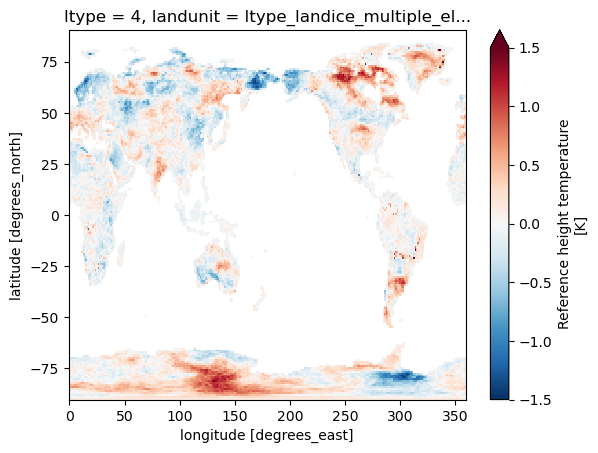

In [36]:
qdelta_right_shift_1deg.plot(cmap="RdBu_r", vmin=-1.5, vmax=1.5)

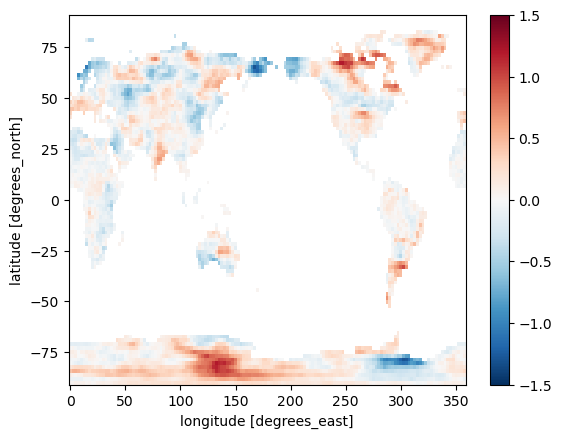

In [35]:
qdelta_right_shift_wavg_2deg.plot(cmap="RdBu_r", vmin=-1.5, vmax=1.5)

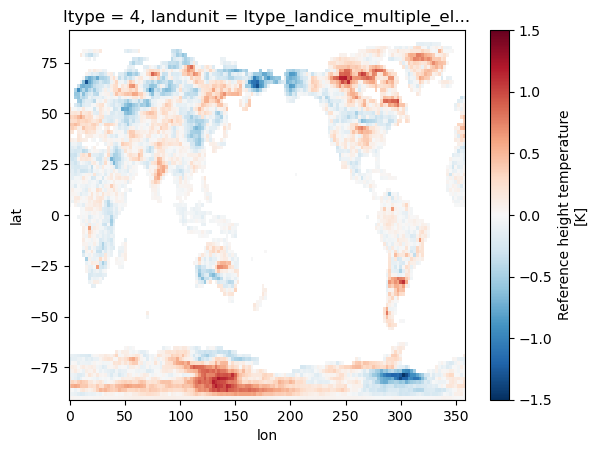

In [37]:
qdelta_right_shift_2deg.plot(cmap="RdBu_r", vmin=-1.5, vmax=1.5)

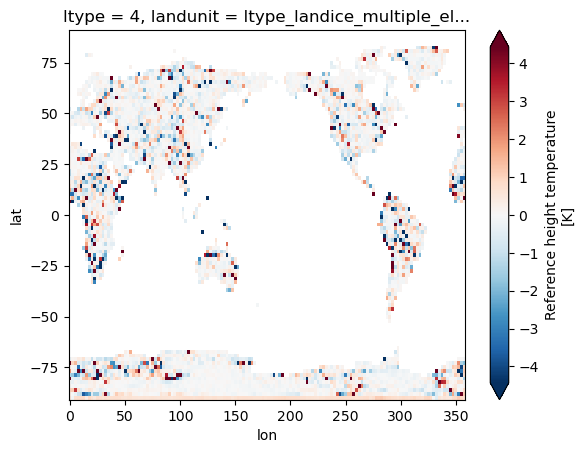

In [48]:
(1 - qdelta_right_shift_2deg / qdelta_right_shift_wavg_2deg).plot(cmap="RdBu_r", robust=True)

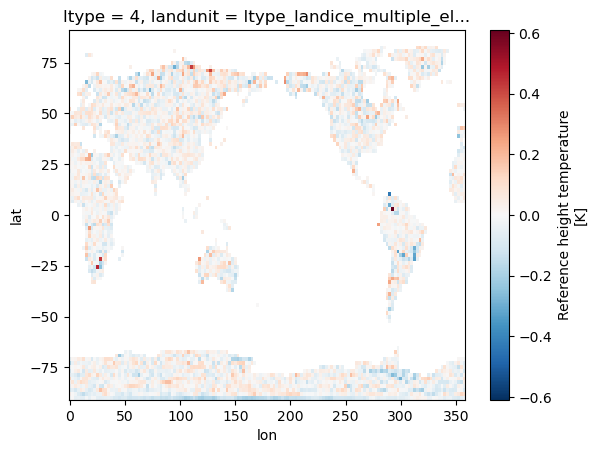

In [43]:
(qdelta_right_shift_2deg - qdelta_right_shift_wavg_2deg).plot(cmap="RdBu_r")